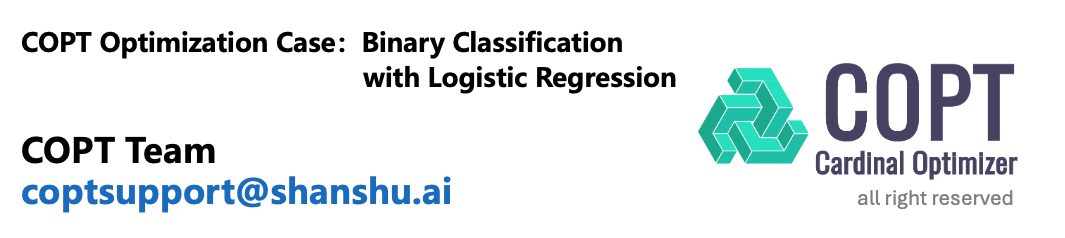

> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib numpy


# Binary Classification Problem Code Implementation

## Steps to Model and Solve Binary Classification with Logistic Regression Problem Using COPT

To model and solve a binary logistic regression problem using COPT in Python, the basic steps are as follows:

1. Import the COPT-Python interface library `coptpy`

2. Load/import sample data features and corresponding label indices

3. Create the `COPT` environment and `COPT` model

4. Build the model by adding the three key modeling components:

- Add decision variables: variables can be added in batches, or efficiently added in high-dimensional form by constructing matrix variables via the `MVar` class
- Set the objective function: nonlinear expressions can be built using the `nl` namespace
- Add constraints: for expressions involving nonlinear terms, use `LinExpr` (linear expression) and `QuadExpr` (quadratic expression) classes to construct objects, and then iteratively add expression items;
- (Add cone constraints: `Model.addExpCone([x,y,z], COPT.EXPCONE_PRIMAL)` requires standardized input (each variable must be a single element); `Model.addAffineCone()` can directly accept affine-form cone inputs, first instantiated via the `AffineConeBuilder` class to construct the required affine object for complex cones.)

5. Solve the model

6. View and analyze results

<font color=#0000FF>
<b>Note: The application of COPT's affine cone and exponential cone modules requires COPT 7.2.4 or above.</b>
</font>

## Import COPT-Python API

In [1]:
import coptpy as cp
from coptpy import COPT,nl

## Add Model Data
`point_data` refers to the 35 known data points, where the keys of `point_data` are the point indices, and the corresponding values are the features `[feature1, feature2]` and the class label `class`.

For example, `3: [[4.2, 0.4], 0]` means that the point index is `3`, the features are `[4.2, 0.4]`, and the class label is `0`.

In [4]:
# point: [[feature1, feature2], class]
point_data = {
    1: [[0.2, 1.8], 0],
    2: [[2.5, 1.7], 0],
    3: [[4.2, 0.4], 0],
    4: [[0.9, 3.7], 0],
    5: [[0.3, 2.3], 0],
    6: [[1.0, 2.9], 0],
    7: [[0.4, 4.0], 0],
    8: [[1.2, 1.6], 0],
    9: [[2.95, 1.05], 0],
    10: [[4.0, 5.0], 1],
    11: [[1.8, 3.9], 1],
    12: [[1.2, 5.1], 1],
    13: [[4.1, 1.8], 1],
    14: [[3.9, 5.2], 1],
    15: [[3.3, 5.0], 1],
    16: [[3.0, 4.7], 1],
    17: [[2.1, 4.8], 1],
    18: [[3.5, 2.3], 1],
    19: [[0.85, 4.95], 1],
    20: [[1.5, 3.0], 0],
    21: [[1.9, 2.8], 0],
    22: [[2.7, 2.1], 0],
    23: [[1.0, 0.7], 0],
    24: [[1.4, 3.6], 0],
    25: [[3.0, 4.0], 1],
    26: [[4.2, 3.2], 1],
    27: [[2.9, 3.8], 1],
    28: [[3.0, 5.1], 1],
    29: [[4.0, 3.5], 1],
    30: [[0.8, 4,0], 1],
    31: [[3.5, 1.0], 1],
    32: [[1.5, 4.2], 0],
    33: [[2.5, 4.0], 0],
    34: [[3.7, 1.9], 0],
    35: [[1.0, 2.0], 0],
}

We use COPT's `multidict(data)` method to extract the `point_index`, `point_feature`, and `point_class` from `point_data` respectively, which facilitates plotting and subsequent processing.

In [7]:
point_index, point_feature, point_class = cp.multidict(point_data)

print('point_index:', point_index)
print('\npoint_feature:', point_feature)
print('\npoint_class:', point_class)

point_index: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]

point_feature: {1: [0.2, 1.8], 2: [2.5, 1.7], 3: [4.2, 0.4], 4: [0.9, 3.7], 5: [0.3, 2.3], 6: [1.0, 2.9], 7: [0.4, 4.0], 8: [1.2, 1.6], 9: [2.95, 1.05], 10: [4.0, 5.0], 11: [1.8, 3.9], 12: [1.2, 5.1], 13: [4.1, 1.8], 14: [3.9, 5.2], 15: [3.3, 5.0], 16: [3.0, 4.7], 17: [2.1, 4.8], 18: [3.5, 2.3], 19: [0.85, 4.95], 20: [1.5, 3.0], 21: [1.9, 2.8], 22: [2.7, 2.1], 23: [1.0, 0.7], 24: [1.4, 3.6], 25: [3.0, 4.0], 26: [4.2, 3.2], 27: [2.9, 3.8], 28: [3.0, 5.1], 29: [4.0, 3.5], 30: [0.8, 4, 0], 31: [3.5, 1.0], 32: [1.5, 4.2], 33: [2.5, 4.0], 34: [3.7, 1.9], 35: [1.0, 2.0]}

point_class: {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 0, 33: 0, 34: 0, 35: 0}


Plot the data points.

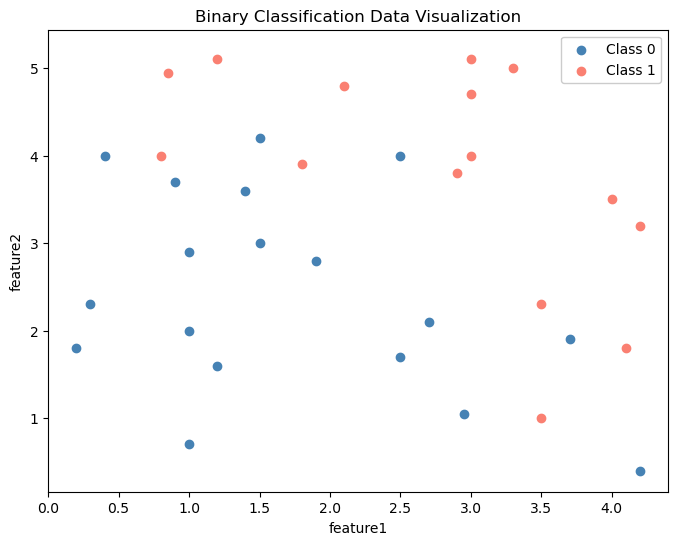

In [10]:
import matplotlib.pyplot as plt

point_class0 = [point_feature[index] for index in point_index if point_class[index] == 0]  # 类别 0
point_class1 = [point_feature[index] for index in point_index if point_class[index] == 1]  # 类别 1

plt.figure(figsize=(8, 6))
plt.scatter([x[0] for x in point_class0], [x[1] for x in point_class0], c='steelblue', label='Class 0')
plt.scatter([x[0] for x in point_class1], [x[1] for x in point_class1], c='salmon', label='Class 1')

plt.xlabel('feature1')
plt.ylabel('feature2')
plt.title('Binary Classification Data Visualization')
plt.legend(loc='upper right', facecolor='white', framealpha=1.0)
plt.show()

## Problem 1: Solving with the Nonlinear Module
We directly solve the unconstrained nonlinear problem.

## Create Model
Create a model named `binary_classification_q1` as `model_1`.

In [13]:
env = cp.Envr()
model_1 = env.createModel("binary_classification_q1")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



Add the model regularization parameter `lamda` (i.e., $\lambda$), the number of samples `n_samples`, and the number of features per sample `n_features`.

In [16]:
lamda = 0
n_samples = len(point_index)
n_features = len(point_feature[1])

## Add three core components of COPT Model

### Add Decision Variables

Add decision variables $\{w_j\}^{n\_features}_{j=1}$ and $b$.

<font color=#0000FF>
<b>Tip: Add variables in batch:</b>
</font>

When adding decision variables in batch, for `Model.addVars(*indices, lb=-COPT.INFINITY, ub=COPT.INFINITY, obj=0.0, vtype=COPT.CONTINUOUS, nameprefix="w")`, we can simply input `n_features` as `*indices` to create the required $n\_features$ decision variables. Note that in the model, the index of decision variables starts from `0` and ends at `n_features - 1`, so the mathematical variables $w_1$, $w_2$, ... correspond to `w(0)`, `w(1)`, ... in the model output.

If we want to customize the indices of decision variables, we can set `*indices` to a list of desired indices. For example, in this case we can also set it as `[1, 2]` to generate `w(1)`, `w(2)`, but be sure to handle the mapping carefully in subsequent calculations.

In [20]:
w = model_1.addVars(n_features, lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix='w')
b = model_1.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY,name="b")

### Set Objective Function

The objective function is
$$
\min_{\mathbf{w}\in \mathbb{R}^2, b \in \mathbb{R}}\ \lambda\| \mathbf{w} \|_2^2 + \sum_{i=1}^n  y_i \cdot \log(1 + e^{-(\mathbf{w}^\top \mathbf{x}_i + b)}) + (1 - y_i) \cdot \log(1 + e^{\mathbf{w}^\top \mathbf{x}_i + b})
$$

In [24]:
obj_model_1 = 0

# Use a loop to compute the summation of the logistic loss function
for index in point_index:
    xi = point_feature[index]
    yi = point_class[index]
    linear_expr = cp.quicksum(w[j] * xi[j] for j in range(n_features)) + b
    obj_model_1 += yi * nl.log(1 + nl.exp(-linear_expr)) + (1 - yi) * nl.log(1 + nl.exp(linear_expr))

# Add L2 regularization term: lambda * w^2
obj_model_1 += lamda * cp.quicksum(w[j]*w[j] for j in range(n_features))

model_1.setObjective(obj_model_1, cp.COPT.MINIMIZE)

<font color=#0000FF>
<b>Tip: Use COPT nl namespace to construct required nonlinear operations in expressions</b>
</font>

COPT's native modeling interface allows direct inclusion of nonlinear function expressions in objectives and constraints.
In the COPT-Python interface, the `nl` namespace provides access to these functions:
`nl.abs()` for absolute value, `nl.sin()` for sine, `nl.exp()` for natural exponential, `nl.sqrt()` for square root, etc.
Thus, we can write expressions in a form close to natural algebra, for example: `nl.log(1 + nl.exp(-linear_expr))`

For other supported nonlinear functions, refer to the [*COPT User Manual: Python API*](https://www.shanshu.ai/copt-document/manual?id=19&docType=3)

<font color=#0000FF>
<b>Tip: Recommended to use quicksum() </b>
</font>

Here we use the helper function `quicksum()` provided by COPT to perform summation operations.
Although it performs the same function as Python’s built-in `sum()`, `quicksum()` offers better performance.
It is optimized for summing expressions during the modeling process, providing faster speed and lower memory usage,
especially beneficial for large-scale problems compared to using `sum()` or the `+` operator directly.

### Add Constraints
This is an unconstrained optimization problem, so no constraints need to be added.

## Solve

In [29]:
model_1.solve()

Model fingerprint: 8650d832

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing an NLP problem

The original problem has:
    0 rows, 3 columns and 0 non-zero elements
    588 nonlinear expression objective elements

The presolved problem has:
    0 rows, 3 columns and 0 non-zero elements
    588 nonlinear expression objective elements

Starting NLP barrier solver using 4 threads

Iter     Objective            Compl       Primal.Inf         Dual.Inf       Time
   0  +2.42601513e+01  +0.00000000e+00  +0.00000000e+00  +1.18000000e+01   0.00s
   1  +1.36301685e+01  +0.00000000e+00  +0.00000000e+00  +3.10465641e+00   0.00s
   2  +1.16705225e+01  +0.00000000e+00  +0.00000000e+00  +1.18570522e+00   0.00s
   3  +1.12125564e+01  +0.00000000e+00  +0.00000000e+00  +3.33284580e-01   0.00s
   4  +1.11735952e+01  +0.00000000

The above is the solver log from the interior-point method used for solving the nonlinear programming (NLP) model. From the model statistics section, we can observe the number of nonlinear terms included in the objective function.

## Retrieve Results

In [33]:
if model_1.status in (COPT.OPTIMAL, COPT.LOCAL_OPTIMAL):
  print("\nOptimal objective value:")
  print(" {0:.3e}".format(model_1.objval))

  print("\nVariable solution:")
  vars_model_1 = model_1.getVars()
  for var in vars_model_1:
    print(" {0} = {1:.3e}".format(var.name, var.x))
else:
  print("\n No solution available")


Optimal objective value:
 1.117e+01

Variable solution:
 w(0) = 1.871e+00
 w(1) = 1.818e+00
 b = -1.008e+01


At this point, we have obtained a data classifier that can predict the class label of a sample with two features. The equation $\mathbf{w}^\top \mathbf{x} + b = 0$ represents the linear classification boundary of our classifier. Since we are using two-dimensional data $\mathbf{x} = [x_1,x_2]^\top$, the boundary line can be written as  $w_1 x_1 + w_2 x_2 + b = 0$. We now plot this classification boundary.

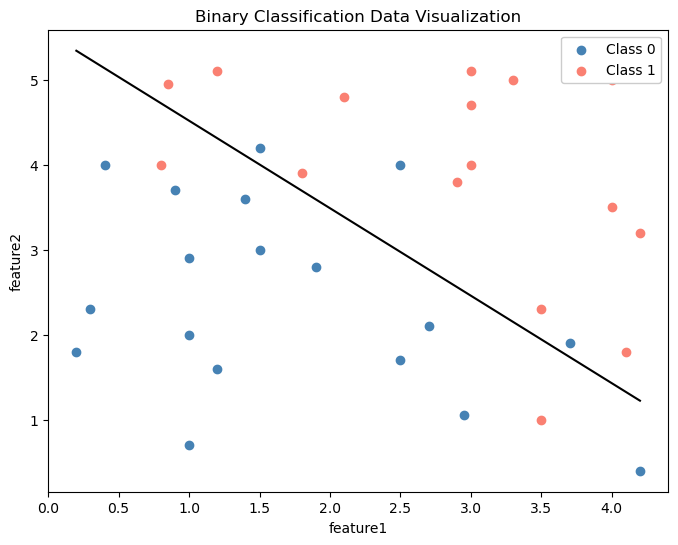

In [36]:
w_res_model_1 = [w[j].x for j in range(n_features)]
b_res_model_1 = b.x

boundary_feature1 = [min(point_feature[index][0] for index in point_index), max(point_feature[index][0] for index in point_index)]
boundary_feature2 = [-(w_res_model_1[0] * feature1 + b_res_model_1)/w_res_model_1[1] for feature1 in boundary_feature1]

plt.figure(figsize=(8, 6))
plt.plot(boundary_feature1, boundary_feature2, color='black')
plt.scatter([x[0] for x in point_class0], [x[1] for x in point_class0], c='steelblue', label='Class 0')
plt.scatter([x[0] for x in point_class1], [x[1] for x in point_class1], c='salmon', label='Class 1')

plt.xlabel("feature1")
plt.ylabel("feature2")
plt.title("Binary Classification Data Visualization")
plt.legend(loc='upper right', facecolor='white', framealpha=1.0)
plt.show()

## Problem 2: Solving with the Exponential Cone Module
We reformulate the original problem as an optimization problem with exponential cone constraints.

## Create Model
Create a model named `binary_classification_q2` as `model_2`.

In [39]:
env = cp.Envr()
model_2 = env.createModel("binary_classification_q2")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



Add the model regularization parameter `lamda` (i.e., $\lambda$), the number of samples `n_samples`, and the number of features per sample `n_features`.

In [42]:
lamda = 0
n_samples = len(point_index)
n_features = len(point_feature[1])

## Add the Three Key Components of the Model

### Add Decision Variables
Add decision variables $\{w_j\}^{n\_features}_{j=1}$ and $b$.

Add auxiliary variables for the model: $\{t_i\}^{n\_samples}_{i=1}$, $\{m_i\}^{n\_samples}_{i=1}$, $\{t\_minus_i\}^{n\_samples}_{i=1}$, $\{ones_i\}^{n\_samples}_{i=1}$, $\{u_i\}^{n\_samples}_{i=1}$, $\{v_i\}^{n\_samples}_{i=1}$, and $r$.

For $\{ones_i\}^{n\_samples}_{i=1}$, we set both the lower and upper bounds to 1 in order to fix their value to 1.


In [45]:
w = model_2.addVars(n_features, lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix="w")
b = model_2.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY, name="b")
t = model_2.addVars(point_index, lb=0, ub=COPT.INFINITY, nameprefix="t")
m = model_2.addVars(point_index, lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix="m")
t_minus = model_2.addVars(point_index, lb=-COPT.INFINITY, ub=0, nameprefix="t")
ones = model_2.addVars(point_index, lb=1.0, ub=1.0)
u = model_2.addVars(point_index, lb=0, ub=1, nameprefix="u")
v = model_2.addVars(point_index, lb=0, ub=1, nameprefix="v")
r = model_2.addVar(lb=0, ub=COPT.INFINITY, name="r")

### Set Objective Function
The objective function is
$$
\min_{\mathbf{w}\in \mathbb{R}^2, b \in \mathbb{R}} \sum_{i=1}^n t_i + \lambda r
$$

In [48]:
obj_model_2 = cp.quicksum(t[index] for index in point_index) + lamda * r
model_2.setObjective(obj_model_2, COPT.MINIMIZE)

### Add Constraints
**1. Linear Constraints**

\begin{aligned}
m_i &= \begin{cases}
-(\mathbf{w}^\top \mathbf{x}_i + b)-t_i,\ &\text{if } y_i = 1 \\
(\mathbf{w}^\top \mathbf{x}_i + b)-t_i,\ &\text{if } y_i = 0 \\
\end{cases}\ & i = 1,...,n;\\
-t_i &= t\_minus_i,& i = 1,...,n; \\
u_i + v_i &\leq 1,& i = 1,...,n; \\
\end{aligned}

In [51]:
model_2.addConstrs(m[index] == -(cp.quicksum(w[j] * point_feature[index][j] for j in range(n_features)) + b) - t[index] for index in point_index if point_class[index] == 1)
model_2.addConstrs(m[index] == (cp.quicksum(w[j] * point_feature[index][j] for j in range(n_features)) + b) - t[index] for index in point_index if point_class[index] == 0)
model_2.addConstrs(t_minus[index] == -t[index] for index in point_index)
model_2.addConstrs(u[index] + v[index] <= 1 for index in point_index)

**2. Exponential Cone Constraints**

In our modeling analysis, by introducing auxiliary variables $ones$ and $t\_minus$, we reformulate the constraints into the standard exponential cone form (composed of single-element variables):

$$
\begin{aligned}
(u_i,ones_i,m_i) &\in K_{\text{exp}},& i = 1,...,n; \\
(v_i,ones_i,t\_minus_i) &\in K_{\text{exp}},& i = 1,...,n; \\
\end{aligned}
$$


In [54]:
for index in point_index:
    coneVars_1 = [u[index], ones[index], m[index]]
    model_2.addExpCone(coneVars_1, COPT.EXPCONE_PRIMAL)
    coneVars_2 = [v[index], ones[index], t_minus[index]]
    model_2.addExpCone(coneVars_2, COPT.EXPCONE_PRIMAL)

**3. Quadratic Constraint**
$$
r \geq \| \mathbf{w} \|_2^2
$$

In [57]:
model_2.addQConstr(r >= cp.quicksum(w[j]*w[j] for j in range(n_features)))

<coptpy.QConstraint: >

## Solve

In [60]:
model_2.solve()

Model fingerprint: 45cae69a

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a CONIC problem

The original problem has:
    105 rows, 214 columns and 315 non-zero elements
    1 quadratic constraints
    70 exponential cones
The presolved problem has:
    110 rows, 254 columns and 325 non-zero elements
    1 cones
    70 exponential cones

Starting barrier solver using 4 CPU threads

Problem info:
    Range of matrix coefficients:    [5e-02,1e+00]
    Range of rhs coefficients:       [5e-01,1e+00]
    Range of bound coefficients:     [4e-01,1e+00]
    Range of cost coefficients:      [1e+00,1e+00]

Factor info:
    Number of dense columns:         0
    Number of matrix entries:        8.880e+02
    Number of factor entries:        8.880e+02
    Number of factor flops:          1.842e+04

Iter       Primal.Ob

## Retrieve Results

In [63]:
if model_2.status == COPT.OPTIMAL:
  print("\nOptimal objective value:")
  print(" {0:.3e}".format(model_2.objval))

  print("\nVariable solution:")
  vars_model_2 = model_2.getVars()
  for var in vars_model_2:
      if var.name.startswith("w") or var.name.startswith("b"):
        print(" {0} = {1:.3e}".format(var.name, var.x))
else:
  print("\n No solution available")


Optimal objective value:
 1.117e+01

Variable solution:
 w(0) = 1.870e+00
 w(1) = 1.818e+00
 b = -1.008e+01


We solve Problem 2 and obtain the parameters $\mathbf{w}$ and $b$ of the data classification model. We then plot the corresponding classification boundary using the same method as before.

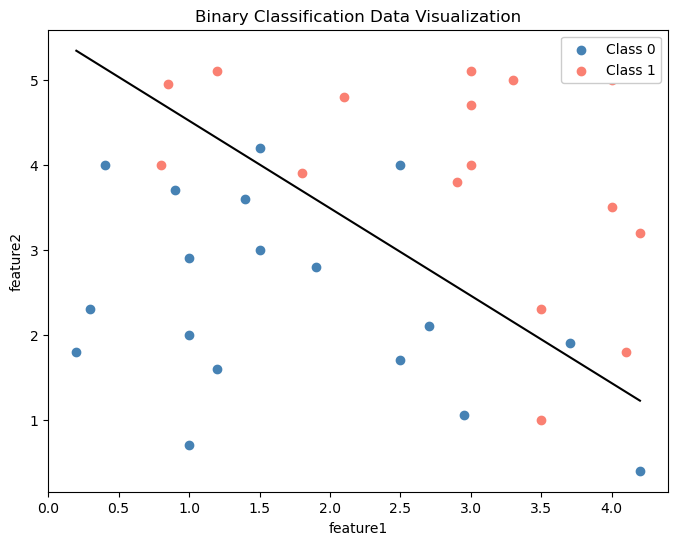

In [66]:
w_res_model_2 = [w[j].x for j in range(n_features)]
b_res_model_2 = b.x

boundary_feature1 = [min(point_feature[index][0] for index in point_index), max(point_feature[index][0] for index in point_index)]
boundary_feature2 = [-(w_res_model_2[0] * feature1 + b_res_model_2)/w_res_model_2[1] for feature1 in boundary_feature1]

plt.figure(figsize=(8, 6))
plt.plot(boundary_feature1, boundary_feature2, color='black')
plt.scatter([x[0] for x in point_class0], [x[1] for x in point_class0], c='steelblue', label='Class 0')
plt.scatter([x[0] for x in point_class1], [x[1] for x in point_class1], c='salmon', label='Class 1')

plt.xlabel("feature1")
plt.ylabel("feature2")
plt.title("Binary Classification Data Visualization")
plt.legend(loc='upper right', facecolor='white', framealpha=1.0)
plt.show()

# Case Expansion: Binary Classification Problem with Nonlinear Classification Boundaries
Suppose we are given a set of sample data along with corresponding class labels.
We can observe that the classification boundary for this data is likely to be nonlinear.
In such cases, a data classifier with a linear boundary will no longer yield good prediction results.
The following code simulates a nonlinear classification boundary, enabling our classifier
to flexibly adapt and make more accurate predictions.

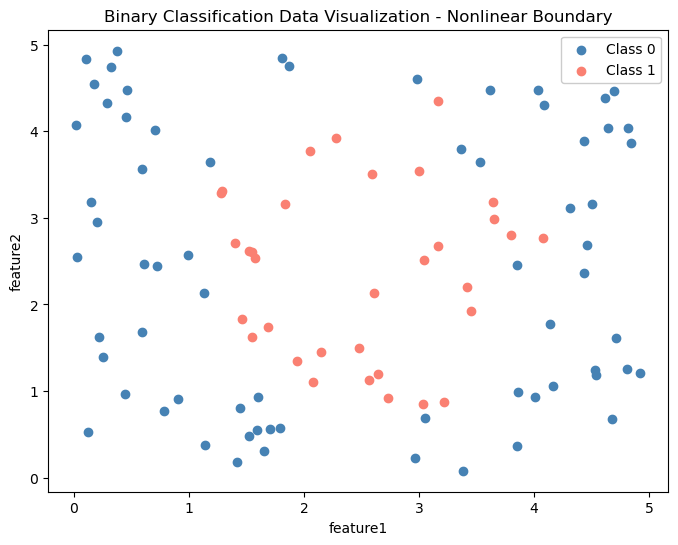

In [69]:
# point: [[feature1, feature2], class]
point_data = {
    1: [[1.87, 4.75], 0], 2: [[3.65, 2.99], 1], 3: [[0.78, 0.77], 0], 4: [[0.29, 4.33], 0], 5: [[3.0, 3.54], 1], 6: [[0.1, 4.84], 0], 7: [[4.16, 1.06], 0], 8: [[0.9, 0.91], 0], 9: [[1.52, 2.62], 1], 10: [[2.15, 1.45], 1], 11: [[3.05, 0.69], 0], 12: [[1.46, 1.83], 1], 13: [[2.28, 3.92], 1], 14: [[0.99, 2.57], 0], 15: [[2.96, 0.23], 0], 16: [[3.03, 0.85], 1], 17: [[0.32, 4.74], 0], 18: [[4.82, 4.04], 0], 19: [[1.52, 0.48], 0], 20: [[3.42, 2.2], 1], 21: [[0.61, 2.47], 0], 22: [[0.17, 4.54], 0], 23: [[1.29, 3.31], 1], 24: [[1.55, 2.6], 1], 25: [[2.73, 0.92], 1], 26: [[4.84, 3.87], 0], 27: [[4.69, 4.47], 0], 28: [[2.98, 4.6], 0], 29: [[0.44, 0.97], 0], 30: [[0.22, 1.62], 0], 31: [[1.94, 1.35], 1], 32: [[4.14, 1.78], 0], 33: [[1.4, 2.71], 1], 34: [[0.7, 4.01], 0], 35: [[0.37, 4.93], 0], 36: [[3.86, 0.99], 0], 37: [[0.02, 4.07], 0], 38: [[3.53, 3.64], 0], 39: [[3.85, 0.37], 0], 40: [[1.79, 0.57], 0], 41: [[4.31, 3.11], 0], 42: [[1.65, 0.31], 0], 43: [[1.55, 1.62], 1], 44: [[3.64, 3.18], 1], 45: [[4.43, 2.36], 0], 46: [[0.59, 3.56], 0], 47: [[3.8, 2.8], 1], 48: [[3.85, 2.46], 0], 49: [[2.61, 2.13], 1], 50: [[0.12, 0.53], 0], 51: [[0.15, 3.18], 0], 52: [[1.57, 2.54], 1], 53: [[4.53, 1.24], 0], 54: [[2.05, 3.77], 1], 55: [[1.14, 0.38], 0], 56: [[1.44, 0.8], 0], 57: [[4.64, 4.04], 0], 58: [[3.16, 4.35], 1], 59: [[4.01, 0.93], 0], 60: [[4.46, 2.69], 0], 61: [[4.03, 4.48], 0], 62: [[1.59, 0.55], 0], 63: [[1.13, 2.13], 0], 64: [[4.09, 4.3], 0], 65: [[0.03, 2.55], 0], 66: [[2.08, 1.11], 1], 67: [[0.59, 1.68], 0], 68: [[4.71, 1.61], 0], 69: [[2.59, 3.51], 1], 70: [[1.81, 4.85], 0], 71: [[4.81, 1.25], 0], 72: [[2.48, 1.5], 1], 73: [[1.42, 0.18], 0], 74: [[3.04, 2.51], 1], 75: [[0.25, 1.39], 0], 76: [[4.54, 1.19], 0], 77: [[0.72, 2.44], 0], 78: [[4.92, 1.21], 0], 79: [[3.36, 3.8], 0], 80: [[1.18, 3.64], 0], 81: [[1.83, 3.16], 1], 82: [[3.16, 2.67], 1], 83: [[0.45, 4.17], 0], 84: [[1.6, 0.93], 0], 85: [[0.2, 2.95], 0], 86: [[3.38, 0.08], 0], 87: [[2.56, 1.13], 1], 88: [[3.22, 0.87], 1], 89: [[3.45, 1.93], 1], 90: [[4.68, 0.68], 0], 91: [[1.7, 0.56], 0], 92: [[4.62, 4.38], 0], 93: [[1.28, 3.29], 1], 94: [[4.08, 2.77], 1], 95: [[2.64, 1.2], 1], 96: [[0.46, 4.48], 0], 97: [[4.5, 3.16], 0], 98: [[1.69, 1.74], 1], 99: [[3.62, 4.48], 0], 100: [[4.43, 3.89], 0]
}

point_index, point_feature, point_class = cp.multidict(point_data)

import matplotlib.pyplot as plt

point_class0 = [point_feature[index] for index in point_index if point_class[index] == 0]  # 类别 0
point_class1 = [point_feature[index] for index in point_index if point_class[index] == 1]  # 类别 1

plt.figure(figsize=(8, 6))
plt.scatter([x[0] for x in point_class0], [x[1] for x in point_class0], c='steelblue', label='Class 0')
plt.scatter([x[0] for x in point_class1], [x[1] for x in point_class1], c='salmon', label='Class 1')

plt.xlabel('feature1')
plt.ylabel('feature2')
plt.title('Binary Classification Data Visualization - Nonlinear Boundary')
plt.legend(loc='upper right', facecolor='white', framealpha=1.0)
plt.show()

In [71]:
env = cp.Envr()
model_3 = env.createModel("binary_classification_q3")
model_3.matrixmodelmode = "experimental"

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



In `model_2`, add the decision variables corresponding to the matrix $ \mathbf{A} $.
Note that $ \mathbf{A} $ is a symmetric matrix, so a symmetry constraint must be added accordingly. Update the equality constraint involving the decision variable $m_i$ by replacing the linear term
$(\mathbf{w}^\top \mathbf{x}_i + b)$ with the new nonlinear form
$(\mathbf{x}_i^\top \mathbf{A} \mathbf{x}_i + \mathbf{w}^\top \mathbf{x}_i + b)$. Modify the regularization-related constraint on the decision variable $r$ to
$r \geq \| \mathbf{A} \|^2_F + \| \mathbf{w} \|_2^2$,
where $\| \mathbf{A} \|^2_F = \sum_{i=1}^{m} \sum_{j=1}^{n} A_{ij}^2$ is the squared Frobenius norm of matrix $\mathbf{A}$.

Create a new model named `binary_classification_q3` as `model_3`,
and configure the model parameters and three main components following the structure of `model_2`.
Solve the model and visualize the result.

In [74]:
lamda = 0
n_samples = len(point_index)
n_features = len(point_feature[1])

In [76]:
# Add 2×2 matrix decision variables A
A = model_3.addMVar(shape=(n_features,n_features), lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix="A")
w = model_3.addVars(n_features, lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix="w")
b = model_3.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY, name="b")
t = model_3.addVars(point_index, lb=0, ub=COPT.INFINITY, nameprefix="t")
u = model_3.addVars(point_index, lb=0, ub=1, nameprefix="u")
v = model_3.addVars(point_index, lb=0, ub=1, nameprefix="v")
r = model_3.addVar(lb=0, ub=COPT.INFINITY, name="r")

In [78]:
obj_model_3 = cp.quicksum(t[index] for index in point_index) + lamda * r
model_3.setObjective(obj_model_3, COPT.MINIMIZE)

<font color=#0000FF>
<b>Tip: Use COPT’s matrix modeling functionality</b>
</font>

COPT currently supports incorporating the `MVar` class into model operations.
`MVar` is a class in the COPT solver used to construct multi-dimensional variables and supports NumPy-style multi-dimensional array operations.
We recommend constructing it via the `Model` class methods `addVars` or `addMVar`.
For detailed parameter descriptions, refer to the [*COPT User Manual: Python API*](https://www.shanshu.ai/copt-document/manual?id=19&docType=3)

In [81]:
# Add symmetry constraints for matrix A
model_3.addConstrs(A[i, j].item() == A[j, i].item() for i in range(n_features) for j in range(i + 1, n_features))

# Add quadratic constraint related to the regularization penalty term
quad_expr = cp.QuadExpr()
quad_expr.addTerms([1.0]*n_features, w.values(), w.values())

for i in range(n_features):
    for j in range(n_features):
        quad_expr.addTerm(1.0, A[i, j].item(), A[i, j].item())

model_3.addQConstr(r >= quad_expr)

<coptpy.QConstraint: >

<font color=#0000FF>
<b>Tip: Use COPT’s LinExpr, QuadExpr, and related methods to construct expressions</b>
</font>

COPT supports multiple methods for constructing expressions.
For simple expressions, you can directly use `+` or `quicksum()` for summation.
However, for more complex expressions—especially those involving sums of quadratic terms—direct accumulation may lead to input errors.
Therefore, it is recommended to use more standardized expression-building methods:

- `LinExpr.addTerm(var, coeff=1.0)`: Adds a single term to the current linear expression.
  `var` is the variable to add, and `coeff` is its coefficient (default is `1.0`).
- `LinExpr.addTerms(vars, coeffs)`: Adds one or more terms to the current linear expression.
  `vars` are the variables and `coeffs` their respective coefficients. Ensure the types of `vars` and `coeffs` match (e.g., both are `list` or `tupledict`).
- `QuadExpr.addTerm(coeff, var1, var2=None)`: Adds a single term to the current quadratic expression.
  `coeff` is the coefficient, `var1` is the first variable, and `var2` is the second variable. If `var2` is `None`, the term is treated as linear.
- `QuadExpr.addTerms(coeffs, vars1, vars2=None)`: Adds one or more terms to the current quadratic expression.
  Same type-matching rules apply as above.

In this case, `A` is an `MVar` object, so each `A[i, j]` is a 0-dimensional `MVar`.
  To use it in `addTerm()`, you must convert it to a scalar `Var` using `MVar.item()`. `w` is a `tupledict` object, while `point_feature[index]` is a `list`.
  To use `addTerms()`, you need to convert `w` into a `list` using `tupledict.values()`.

For detailed parameter descriptions of LinExpr, QuadExpr, and other expression types, refer to the
[*COPT User Manual: Python API*](https://www.shanshu.ai/copt-document/manual?id=19&docType=3).

In the case of a nonlinear classification boundary, the original affine form of the exponential constraint is as follows:

$$
z(\mathbf{x}) = \mathbf{x}^\top \mathbf{A} \mathbf{x} + \mathbf{w}^\top \mathbf{x} + b
$$

$$
t_i \geq \log(1+e^{-z(\mathbf{x})})
\ \Longleftrightarrow \quad
\begin{cases}
u_i + v_i \leq 1 \\
(u_i,1,-z(\mathbf{x})-t_i) \in K_{\text{exp}} \\
(v_i,1,-t_i) \in K_{\text{exp}}
\end{cases}\ ,\ \text{if } y_i = 1\\
$$

$$
t_i \geq \log(1+e^{z(\mathbf{x})})
\ \Longleftrightarrow\quad
\begin{cases}
u_i + v_i \leq 1 \\
(u_i,1,z(\mathbf{x})-t_i) \in K_{\text{exp}} \\
(v_i,1,-t_i) \in K_{\text{exp}}
\end{cases}\ ,\ \text{if } y_i = 0\\
$$

Starting from COPT 7.2.4, **COPT has added support for affine cone modeling, allowing users to directly model complex cone constraints. The components of the cone can now be linear expressions or constants, without the need to introduce auxiliary variables for standard form transformation**. Therefore, we demonstrate how to directly add exponential cone constraints in affine form. This approach effectively controls the number of variables in the problem, offers user-friendly modeling, and closely resembles the algebraic form above.


In [85]:
# Add exponential cone constraints: construct affine cones directly without using auxiliary variables
for index in point_index:
    # Construct the nonlinear boundary expression z(x)
    lin_expr = cp.LinExpr()
    for i in range(n_features):
        for j in range(n_features):
            lin_expr.addTerm(A[i, j].item(), point_feature[index][i] * point_feature[index][j])
    lin_expr.addTerms(w.values(), point_feature[index])
    lin_expr.addTerm(b)

    model_3.addConstr(u[index] + v[index] <= 1)

    # Add exponential cone constraints - Method 1: Construct affine cones directly without auxiliary variables
    afcone_1 = cp.AffineConeBuilder()
    afcone_2 = cp.AffineConeBuilder()
    if point_class[index] == 1:
        afcone_1.setBuilder(COPT.EXPCONE_PRIMAL, [u[index], 1, - lin_expr - t[index]])
    else:
        afcone_1.setBuilder(COPT.EXPCONE_PRIMAL, [u[index], 1, lin_expr - t[index]])
    afcone_2.setBuilder(COPT.EXPCONE_PRIMAL, [v[index], 1, - t[index]])
    model_3.addAffineCone(afcone_1)
    model_3.addAffineCone(afcone_2)

<font color=#0000FF>
<b>Tip: Use COPT’s AffineConeBuilder class and Model.addAffineCone() to construct and add affine cones</b>
</font>

The `AffineConeBuilder` class in COPT serves as a constructor for affine cone constraints.
Using its member methods, we can define cone expressions directly—without introducing auxiliary variables.

- `AffineConeBuilder()`: Creates an empty `AffineConeBuilder` object.
- `AffineConeBuilder.setBuilder(conetype, exprs)`: Sets up the affine cone.
  `conetype` is the cone type (set as `COPT.EXPCONE_PRIMAL` in our case), and `exprs` are the mathematical expressions forming the cone.
  These expressions can be linear or semidefinite.
- `Model.addAffineCone(exprs, ctype=None, name="")`: Adds an affine cone to the model.
  `exprs` can be either an `AffineConeBuilder` object or a multi-dimensional array of expressions.
  If `exprs` is an `AffineConeBuilder` object, the `ctype` parameter will be ignored.

For more member methods and detailed parameter instructions of `AffineConeBuilder` and `Model.addAffineCone()`,
refer to the [*COPT User Manual: Python API*](https://www.shanshu.ai/copt-document/manual?id=19&docType=3).

Of course, we can still construct auxiliary variables to first convert the expression into the standard exponential cone form, and then use ``Model.addExpCone()`` to input the constraint into the model. The implementation is shown as follows:

In [89]:
# # Add exponential cone constraints - Method 2: Use auxiliary variables m and t_minus to construct standard exponential cones
# m = model_3.addVars(point_index, lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix="m")
# t_minus = model_3.addVars(point_index, lb=-COPT.INFINITY, ub=0, nameprefix="t")
# ones = model_3.addVars(point_index, lb=1.0, ub=1.0)
# model_3.addConstr(t_minus[index] == -t[index])
# if point_class[index] == 1:
#     model_3.addConstr(m[index] == - lin_expr - t[index])
# else:
#     model_3.addConstr(m[index] == lin_expr - t[index])
# coneVars_1 = [u[index], ones[index], m[index]]
# model_3.addExpCone(coneVars_1, COPT.EXPCONE_PRIMAL)
# coneVars_2 = [v[index], ones[index], t_minus[index]]
# model_3.addExpCone(coneVars_2, COPT.EXPCONE_PRIMAL)

In [91]:
model_3.solve()

Model fingerprint: 65066b0b

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a CONIC problem

The original problem has:
    101 rows, 308 columns and 202 non-zero elements
    1 quadratic constraints
    200 affine cones
The presolved problem has:
    310 rows, 717 columns and 1320 non-zero elements
    1 cones
    200 exponential cones

Starting barrier solver using 4 CPU threads

Problem info:
    Range of matrix coefficients:    [3e-05,1e+00]
    Range of rhs coefficients:       [5e-01,1e+00]
    Range of bound coefficients:     [4e-01,1e+00]
    Range of cost coefficients:      [1e+00,1e+00]

Factor info:
    Number of dense columns:         0
    Number of matrix entries:        6.296e+03
    Number of factor entries:        6.498e+03
    Number of factor flops:          4.389e+05

Iter       Primal.Obj 

In [93]:
if model_3.status == COPT.OPTIMAL:
  print("\nOptimal objective value:")
  print(" {0:.3e}".format(model_3.objval))

  print("\nVariable solution:")
  vars_model_3 = model_3.getVars()
  for var in vars_model_3:
      if var.name.startswith("A") or var.name.startswith("w") or var.name.startswith("b"):
        print(" {0} = {1:.3e}".format(var.name, var.x))
else:
  print("\n No solution available")


Optimal objective value:
 1.221e+01

Variable solution:
 A(0,0) = -4.373e+00
 A(0,1) = -3.688e-01
 A(1,0) = -3.688e-01
 A(1,1) = -2.346e+00
 w(0) = 2.407e+01
 w(1) = 1.385e+01
 b = -3.954e+01


Next, we plot the nonlinear classification boundary obtained from the solution.

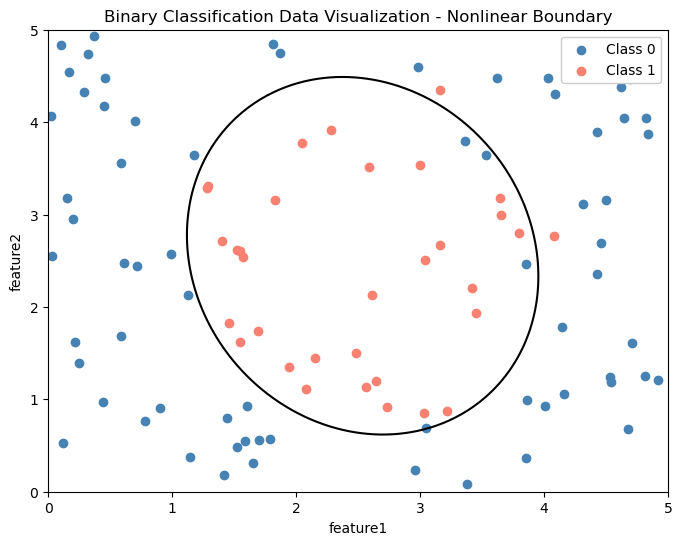

In [96]:
import numpy as np
import matplotlib.pyplot as plt

A_res_model_3 = np.array([[A[i, j].x for i in range(n_features)] for j in range(n_features)])
w_res_model_3 = np.array([w[j].x for j in range(n_features)])
b_res_model_3 = b.x

def quadratic_curve(x, A, w, b):
    return x.T @ A @ x + w.T @ x + b

feature1 = np.linspace(0, 5, 100)
feature2 = np.linspace(0, 5, 100)
F1, F2 = np.meshgrid(feature1, feature2)

Z = np.zeros_like(F1)
for i in range(F1.shape[0]):
    for j in range(F1.shape[1]):
        x = np.array([F1[i, j], F2[i, j]])
        Z[i, j] = quadratic_curve(x, A_res_model_3, w_res_model_3, b_res_model_3)

plt.figure(figsize=(8, 6))
contour = plt.contour(F1, F2, Z, levels=[0], colors='black')
plt.scatter([x[0] for x in point_class0], [x[1] for x in point_class0], c='steelblue', label='Class 0')
plt.scatter([x[0] for x in point_class1], [x[1] for x in point_class1], c='salmon', label='Class 1')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.title("Binary Classification Data Visualization - Nonlinear Boundary")
plt.legend(loc='upper right', facecolor='white', framealpha=1.0)
plt.show()